In [1]:
import pandas as pd

df = pd.read_csv("loan_prediction.csv")
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [2]:
import os
print(os.listdir())


['.config', 'loan_prediction.csv', 'sample_data']


Loan Approval Prediction Using Machine Learning

Objective

The objective of this project is to build a supervised machine learning model to predict whether a loan application will be approved based on applicant information. The project includes data preprocessing, exploratory data analysis, handling class imbalance, model training, evaluation, and business interpretation.

In [3]:
!pip install imbalanced-learn seaborn

Import Required Libraries

This step imports all the Python libraries required for data preprocessing, visualization, machine learning, and model evaluation.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

Import Google Colab Files Module

This module is used to upload the dataset from the local computer into the Google Colab environment.

In [5]:
from google.colab import files

Upload Dataset

The loan prediction dataset is uploaded into the Colab environment for further analysis.

In [8]:
# uploaded = files.upload('loan_prediction.csv')

Load Dataset

The uploaded dataset is loaded into a Pandas DataFrame and the first five rows are displayed.

In [9]:
df = pd.read_csv("loan_prediction.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Dataset Dimensions

The total number of rows and columns present in the dataset are displayed.

In [10]:
df.shape

(614, 13)

Dataset Information

The dataset information displays the column names, data types, and the number of non-null values.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


Display Column Names

The names of all columns in the dataset are displayed for reference during preprocessing and model building.

In [12]:
df.isnull().sum()
df.describe()
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Remove Unnecessary Column

The Loan_ID column is removed because it is a unique identifier and does not contribute to predicting loan approval.

In [13]:
df.drop("Loan_ID", axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Handle Missing Values in Categorical Columns

Missing values in categorical columns are replaced with the most frequently occurring value to preserve data consistency.

In [14]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

Fill Missing Categorical Values

The mode value of each categorical column is used to replace missing values.

In [15]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df[cat_cols].isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Property_Area,0
Loan_Status,0


Identify Numerical Columns

The numerical columns are identified for preprocessing and scaling.

In [16]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

Fill Missing Numerical Values

Missing values in numerical columns are replaced using the median value of each column.

In [17]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

df[num_cols].isnull().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


Encode Categorical Variables

Categorical values are converted into numerical values using Label Encoding for machine learning.

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

Apply Label Encoding

Each categorical column is transformed into numerical values for model training.

In [19]:
for col in cat_cols:
    df[col] = encoder.fit_transform(
        df[col]
    )

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


Separate Features and Target Variable

The input features and target variable are separated for machine learning.

In [20]:
X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]

Scale Numerical Features

Feature scaling is performed using StandardScaler to improve model performance.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

Split the Dataset

The dataset is divided into training and testing sets for model training and evaluation.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Analyze Class Distribution

Before training the machine learning models, it is important to examine the distribution of the target variable. This helps determine whether the dataset is balanced or imbalanced and whether techniques such as SMOTE are required to improve model performance.

Class Distribution

Loan_Status
1    422
0    192
Name: count, dtype: int64



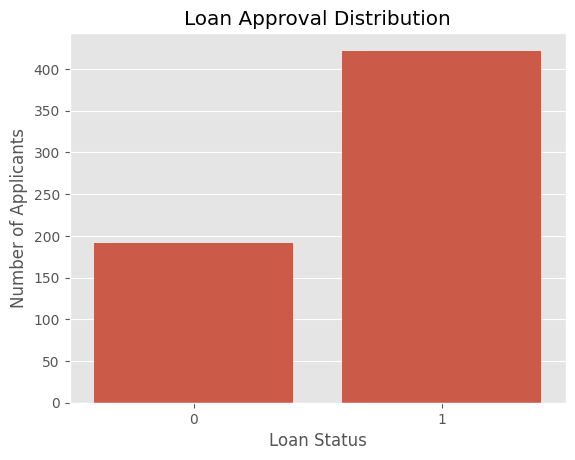

In [23]:
print("Class Distribution")

print()

print(df["Loan_Status"].value_counts())

print()

sns.countplot(
    x="Loan_Status",
    data=df
)

plt.title("Loan Approval Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Number of Applicants")

plt.show()

Handle Class Imbalance Using SMOTE

Synthetic Minority Over-sampling Technique (SMOTE) is used to balance the classes by generating synthetic samples for the minority class. This helps the machine learning models learn from both classes more effectively.

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)

print(y_train_smote.value_counts())

(684, 11)
Loan_Status
0    342
1    342
Name: count, dtype: int64


Import Machine Learning Models

The required machine learning algorithms are imported for training and comparing different classification models. Logistic Regression, Decision Tree, and Random Forest are selected for this project.

In [25]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

Train Logistic Regression Model

Logistic Regression is a supervised classification algorithm that predicts whether a loan application will be approved or rejected based on applicant information.

In [26]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr.predict(
    X_test
)

Train Decision Tree Model

Decision Tree is a tree-based machine learning algorithm that classifies loan applications by learning decision rules from the training data.

In [27]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_smote,
    y_train_smote
)

dt_pred = dt.predict(
    X_test
)

Train Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [28]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf.predict(
    X_test
)

Model Evaluation and Business Interpretation

In this final step, the trained machine learning models are evaluated using various performance metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC. The models are compared to identify the best-performing algorithm. Confusion matrix, ROC curve, and feature importance are visualized to understand model performance. Finally, business-oriented recommendations and deployment suggestions are provided based on the analysis.

Logistic Regression
Accuracy : 0.7723577235772358
Precision: 0.776595744680851
Recall   : 0.9125
F1 Score : 0.8390804597701149
ROC-AUC  : 0.7120639534883721

Decision Tree
Accuracy : 0.6422764227642277
Precision: 0.725
Recall   : 0.725
F1 Score : 0.725
ROC-AUC  : 0.6066860465116279

Random Forest
Accuracy : 0.7235772357723578
Precision: 0.7446808510638298
Recall   : 0.875
F1 Score : 0.8045977011494253
ROC-AUC  : 0.6584302325581395

Model Comparison

                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.772358   0.776596  0.9125  0.839080  0.712064
1        Decision Tree  0.642276   0.725000  0.7250  0.725000  0.606686
2        Random Forest  0.723577   0.744681  0.8750  0.804598  0.658430


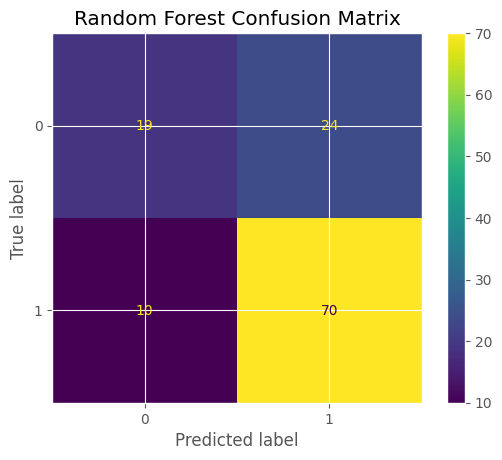

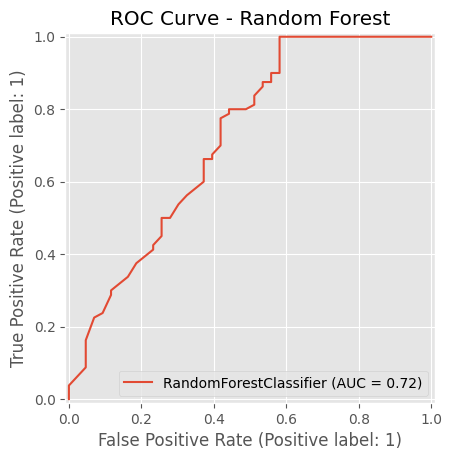

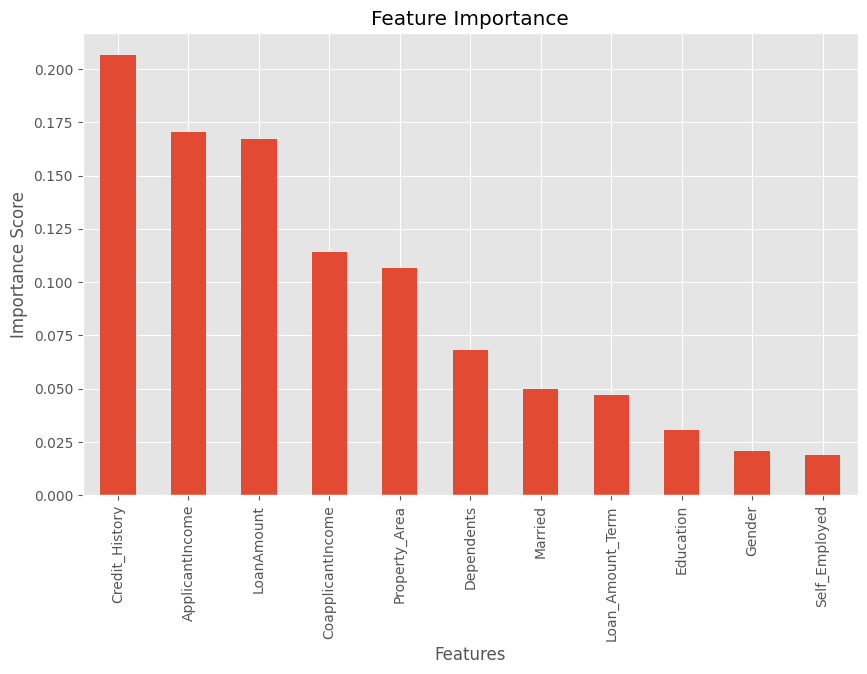


Business Interpretation

• Applicants with good credit history are more likely to receive loan approval.
• Applicant income and loan amount significantly influence approval decisions.
• Random Forest generally provides better prediction performance because it combines multiple decision trees.
• Financial institutions can use this model to reduce manual verification time and improve decision consistency.

Deployment Recommendations

1. Deploy the Random Forest model as it provides better prediction performance compared to other models.
2. Use the model as a decision support system instead of replacing manual verification completely.
3. Continuously retrain the model using new loan application data to improve prediction accuracy.
4. Monitor prediction performance regularly and adjust the approval threshold based on business requirements.
5. Integrate the model into the loan management system to assist bank officers in faster loan approval.

Loan Prediction Project Completed Successfully

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)



lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)



def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_pred))

    print()



evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)



comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred)
    ]

})

print("Model Comparison")
print()

print(comparison)



ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")

plt.show()



RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()



importance = pd.Series(

    rf.feature_importances_,

    index=df.drop(
        "Loan_Status",
        axis=1
    ).columns

)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

importance.plot(
    kind="bar"
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()


print("\nBusiness Interpretation\n")

print("• Applicants with good credit history are more likely to receive loan approval.")

print("• Applicant income and loan amount significantly influence approval decisions.")

print("• Random Forest generally provides better prediction performance because it combines multiple decision trees.")

print("• Financial institutions can use this model to reduce manual verification time and improve decision consistency.")

print()


recommendations = [

"1. Deploy the Random Forest model as it provides better prediction performance compared to other models.",

"2. Use the model as a decision support system instead of replacing manual verification completely.",

"3. Continuously retrain the model using new loan application data to improve prediction accuracy.",

"4. Monitor prediction performance regularly and adjust the approval threshold based on business requirements.",

"5. Integrate the model into the loan management system to assist bank officers in faster loan approval."

]

print("Deployment Recommendations\n")

for rec in recommendations:
    print(rec)

print()

print("Loan Prediction Project Completed Successfully.")